     proto state service       dur  sbytes  dbytes  spkts  dpkts  \
0  pri-enc   INT       -  0.000009     200       0      2      0   
1      tcp   FIN       -  0.049860    3926   57474     66     68   
2      tcp   FIN       -  0.998910     608     646     10     10   
3      tcp   FIN    smtp  0.595864   37492    3172     52     38   
4      udp   INT       -  0.000009     104       0      2      0   

          sload         dload  sttl  dttl  smean  dmean      sinpkt  label  
0  8.888889e+07  0.000000e+00   254     0    100      0    0.009000      1  
1  6.204572e+05  9.086081e+06    31    29     59    845    0.761846      0  
2  4.388784e+03  4.661081e+03   254   252     61     65  110.990000      1  
3  4.936831e+05  4.147255e+04    31    29    721     83   11.676843      0  
4  4.622222e+07  0.000000e+00   254     0     52      0    0.009000      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 16 columns):
 #   Column   Non-Nu

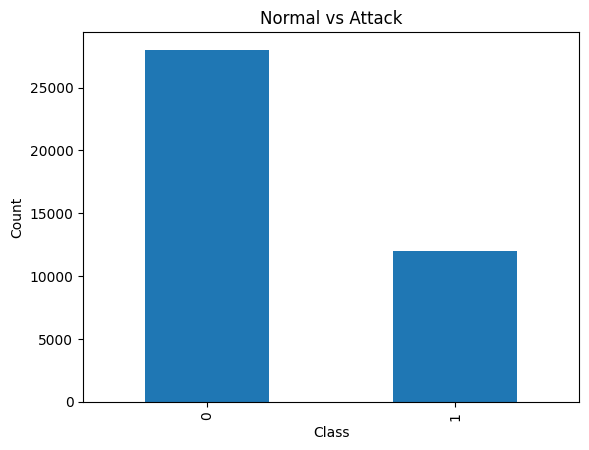

c:\Users\L14\.conda\envs\nids\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Accuracy: 0.8156
Decision Tree Accuracy: 0.9181
Random Forest Accuracy: 0.9243
KNN Accuracy: 0.8752

Confusion Matrix (Random Forest):
[[3124   46]
 [ 711 6119]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.81      0.99      0.89      3170
           1       0.99      0.90      0.94      6830

    accuracy                           0.92     10000
   macro avg       0.90      0.94      0.92     10000
weighted avg       0.94      0.92      0.93     10000



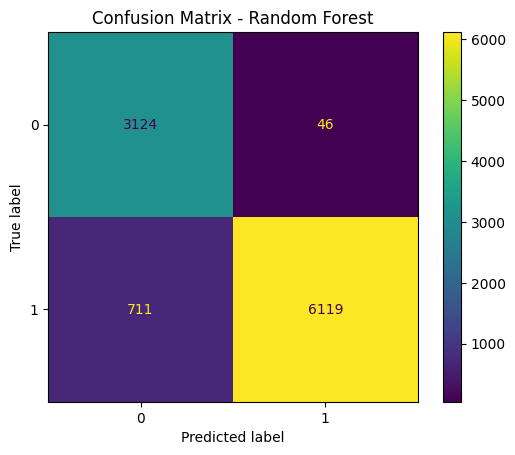

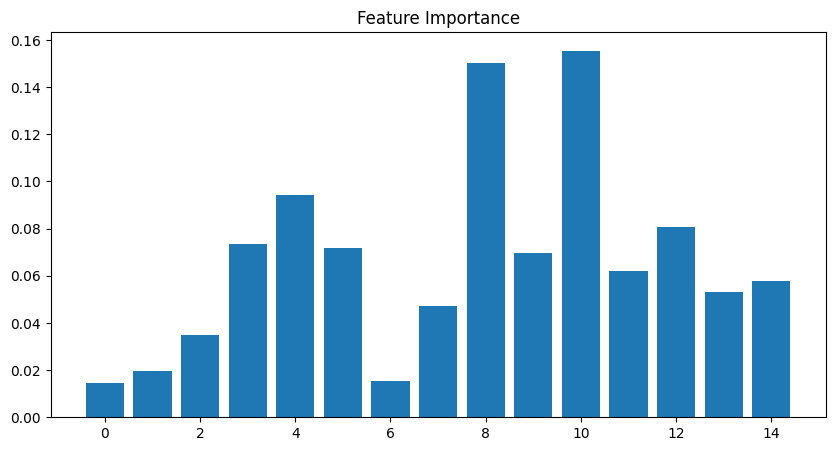

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (FIXED PATH)
train = pd.read_csv("../data/UNSW_NB15_train_40k.csv")
test = pd.read_csv("../data/UNSW_NB15_test_10k.csv")

# Show first rows
print(train.head())

# Check structure
print(train.info())

# Check class distribution
print(train['label'].value_counts())

# Plot class distribution
train['label'].value_counts().plot(kind='bar')
plt.title("Normal vs Attack")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


# ---------------- PREPROCESSING ----------------

from sklearn.preprocessing import LabelEncoder

cols = ['proto', 'service', 'state']

for col in cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.fit_transform(test[col])  # safer


# ---------------- SPLIT ----------------

X_train = train.drop('label', axis=1)
y_train = train['label']

X_test = test.drop('label', axis=1)
y_test = test['label']


# ---------------- MODELS ----------------

from sklearn.metrics import accuracy_score

# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print("Logistic Accuracy:", accuracy_score(y_test, pred_lr))


# Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))


# Random Forest (BEST MODEL)
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))


# KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, pred_knn))


# ---------------- EVALUATION (Random Forest) ----------------

from sklearn.metrics import confusion_matrix, classification_report

print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_test, pred_rf))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, pred_rf))


# ---------------- GRAPH (CONFUSION MATRIX) ----------------

from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, pred_rf))
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()


# ---------------- FEATURE IMPORTANCE (EXTRA MARKS) ----------------

import numpy as np

importances = rf.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()